# Introduction : Analyse du jeu de données MPG

Dans ce tutoriel, nous allons explorer en détail le jeu de données "mpg". Ce jeu de données, initialement publié par la bibliothèque StatLib de l'Université Carnegie Mellon et désormais disponible dans la bibliothèque Seaborn. L'objectif de ce tutoriel est d'explorer la relation entre la consommation de carburant (Miles Per Gallon, ou MPG) et diverses autres caractéristiques de ce jeu de données.

Le jeu de données "mpg" est particulièrement intéressant pour notre étude car il présente une combinaison de caractéristiques discrètes et continues. Il contient :

- 3 caractéristiques discrètes : Ces variables catégorielles nous permettront d'analyser des groupes ou des classifications au sein des données.
- 5 caractéristiques continues : Ces variables numériques nous permettront d'examiner des relations et des tendances quantitatives.

In [1]:
import seaborn as sns
# load a seaborn dataset
mpg_df = sns.load_dataset("mpg")
mpg_df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


In [2]:
## Exploration des données

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Dimensions :", mpg_df.shape)
print("\nTypes et valeurs manquantes :")
print(mpg_df.info())
print("\nStatistiques descriptives :")
mpg_df.describe()

Dimensions : (398, 9)

Types et valeurs manquantes :
<class 'pandas.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    str    
 8   name          398 non-null    str    
dtypes: float64(4), int64(3), str(2)
memory usage: 28.1 KB
None

Statistiques descriptives :


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year
count,398.000000,398.000000,398.000000,392.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,104.469388,2970.424623,15.568090,76.010050
std,7.815984,1.701004,104.269838,38.491160,846.841774,2.757689,3.697627
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000
25%,17.500000,4.000000,104.250000,75.000000,2223.750000,13.825000,73.000000
50%,23.000000,4.000000,148.500000,93.500000,2803.500000,15.500000,76.000000
75%,29.000000,8.000000,262.000000,126.000000,3608.000000,17.175000,79.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000


## Scatter Plots

Les scatter plots permettent d'observer la relation entre deux variables continues. On va ici explorer comment le poids et la puissance influencent la consommation (mpg).

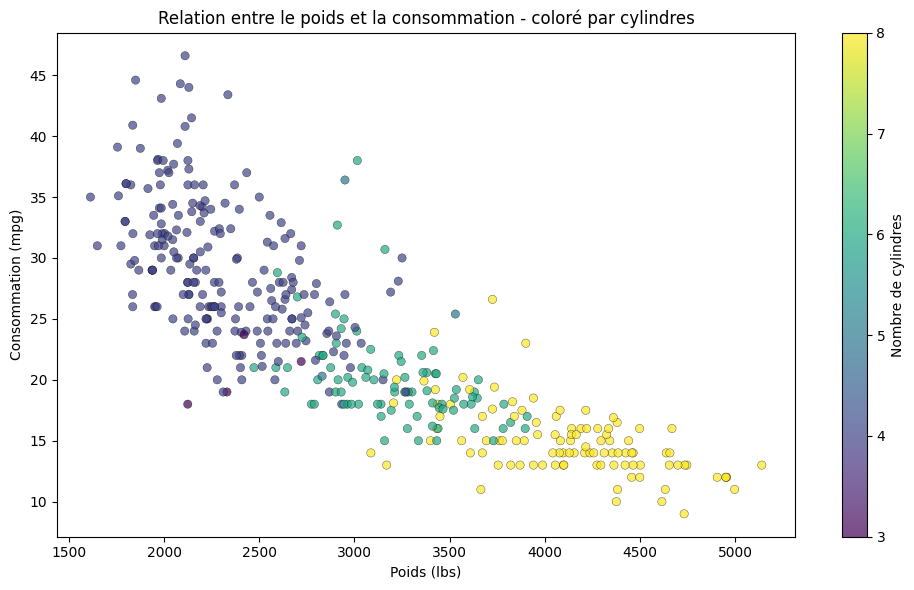

In [3]:
## Scatter Plot 1: MPG vs Poids, coloré par nombre de cylindres

plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    mpg_df['weight'],
    mpg_df['mpg'],
    c=mpg_df['cylinders'],
    cmap='viridis',
    alpha=0.7,
    edgecolors='k',
    linewidths=0.3
)
plt.colorbar(scatter, label='Nombre de cylindres')
plt.xlabel("Poids (lbs)")
plt.ylabel("Consommation (mpg)")
plt.title("Relation entre le poids et la consommation - coloré par cylindres")
plt.tight_layout()
plt.show()

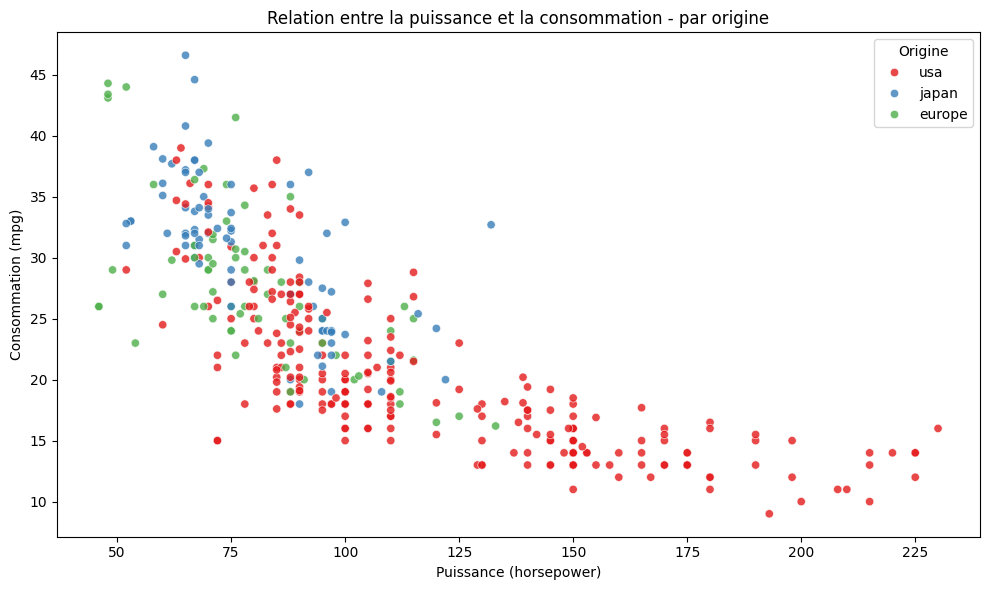

In [4]:
## Scatter Plot 2: MPG vs Puissance, coloré par région d'origine (Seaborn)

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=mpg_df.dropna(subset=['horsepower']),
    x='horsepower',
    y='mpg',
    hue='origin',
    palette='Set1',
    alpha=0.8
)
plt.xlabel("Puissance (horsepower)")
plt.ylabel("Consommation (mpg)")
plt.title("Relation entre la puissance et la consommation - par origine")
plt.legend(title="Origine")
plt.tight_layout()
plt.show()

## Line Plots

Les line plots sont utiles pour visualiser des tendances dans le temps. Ici on va observer l'évolution de la consommation moyenne (mpg) au fil des années de modèle.

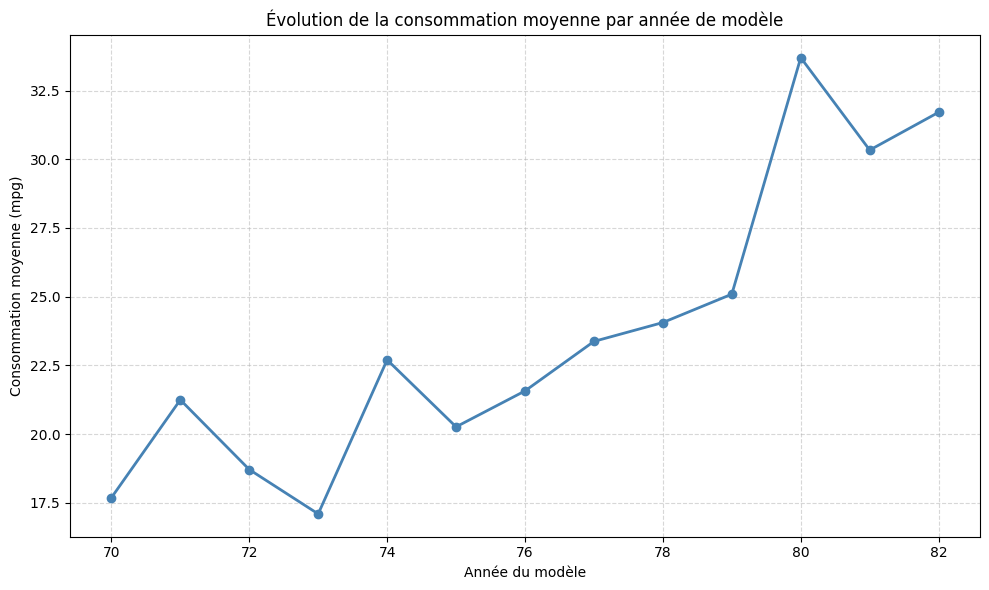

In [5]:
## Line Plot 1: Évolution de la consommation moyenne par année de modèle

avg_mpg_year = mpg_df.groupby('model_year')['mpg'].mean()

plt.figure(figsize=(10, 6))
plt.plot(avg_mpg_year.index, avg_mpg_year.values, marker='o', color='steelblue', linewidth=2)
plt.xlabel("Année du modèle")
plt.ylabel("Consommation moyenne (mpg)")
plt.title("Évolution de la consommation moyenne par année de modèle")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

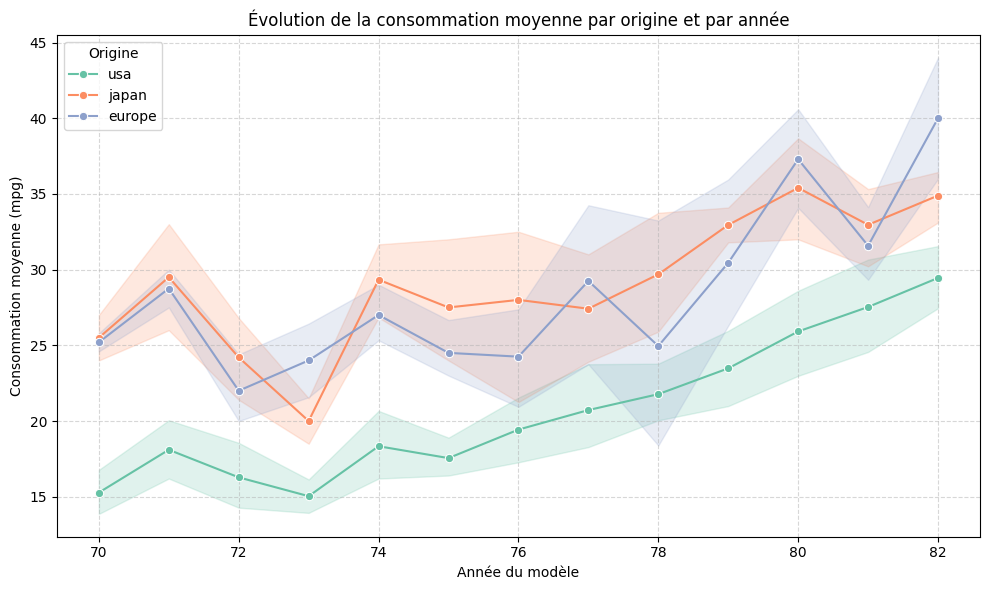

In [6]:
## Line Plot 2: Évolution de la consommation moyenne par année et par origine (Seaborn)

plt.figure(figsize=(10, 6))
sns.lineplot(
    data=mpg_df,
    x='model_year',
    y='mpg',
    hue='origin',
    marker='o',
    palette='Set2'
)
plt.xlabel("Année du modèle")
plt.ylabel("Consommation moyenne (mpg)")
plt.title("Évolution de la consommation moyenne par origine et par année")
plt.legend(title="Origine")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## Heatmaps

Les heatmaps permettent de visualiser la matrice de corrélation entre les variables numériques. Plus la valeur est proche de 1 (ou -1), plus la corrélation entre deux variables est forte (positive ou négative).

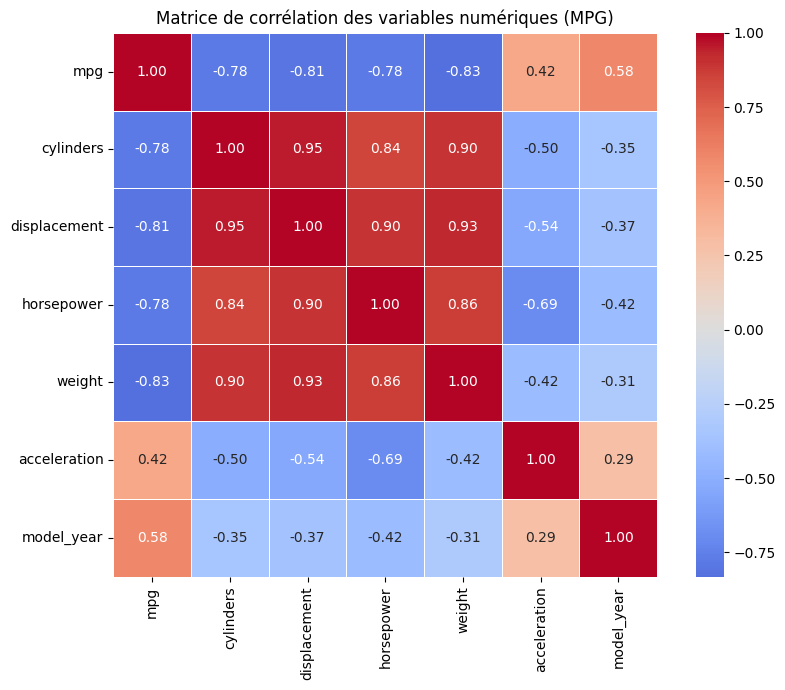

In [7]:
## Heatmap 1: Matrice de corrélation des variables numériques

numeric_cols = ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model_year']
corr_matrix = mpg_df[numeric_cols].dropna().corr()

plt.figure(figsize=(9, 7))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5
)
plt.title("Matrice de corrélation des variables numériques (MPG)")
plt.tight_layout()
plt.show()

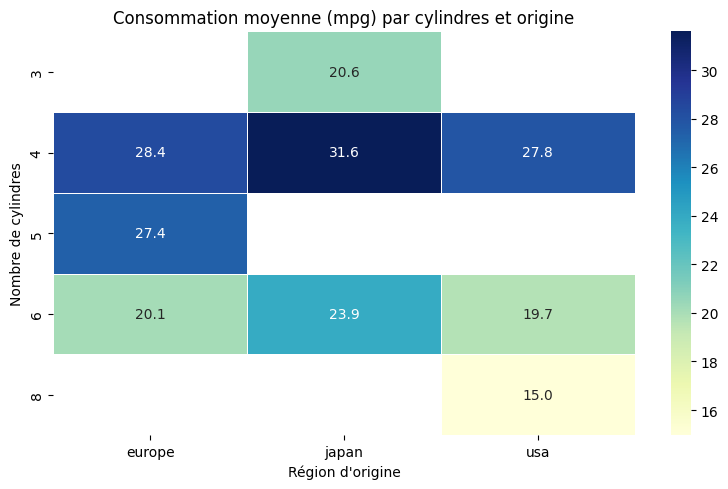

In [8]:
## Heatmap 2: Consommation moyenne par nombre de cylindres et région d'origine

pivot = mpg_df.pivot_table(values='mpg', index='cylinders', columns='origin', aggfunc='mean')

plt.figure(figsize=(8, 5))
sns.heatmap(
    pivot,
    annot=True,
    fmt=".1f",
    cmap='YlGnBu',
    linewidths=0.5
)
plt.title("Consommation moyenne (mpg) par cylindres et origine")
plt.xlabel("Région d'origine")
plt.ylabel("Nombre de cylindres")
plt.tight_layout()
plt.show()